In [1]:
import socket
print(socket.gethostname())

awr-2-04


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from dask.distributed import Client
client = Client(n_workers=8, threads_per_worker=4)

print(client.dashboard_link)
print(client)

http://127.0.0.1:8787/status
<Client: 'tcp://127.0.0.1:41341' processes=8 threads=32, memory=64.00 GiB>


### Pressure & Temperature

* **Mean sea level pressure (slp):** `mean_sea_level_pressure`
* **Surface pressure (p_sfc):** `surface_pressure`
* **2-m dewpoint temperature (Td_2m):** `2m_dewpoint_temperature`
* **2-m temperature (T_2m):** `2m_temperature`
* **Skin temperature (T_sfc):** `skin_temperature`
* **Sea surface temperature:** `sea_surface_temperature` *(Note: In ERA5, Skin Temperature is often used over land/ice, while SST is used over open ocean).*

### Moisture & Transport

* **Integrated water vapor (IWV):** `total_column_water_vapour`
* **Integrated vapor transport (meridional) (IVTV):** `vertical_integral_of_northward_water_vapour_flux`
* **Integrated vapor transport (zonal) (IVTU):** `vertical_integral_of_eastward_water_vapour_flux`

### Wind & Precipitation

* **10-m zonal wind (u_10m_gr):** `10m_u_component_of_wind`
* **10-m meridional wind (v_10m_gr):** `10m_v_component_of_wind`
* **6-hourly accumulated precipitation (precip_bkt):** `total_precipitation`

### Forcing
* **Geopotential at the surface (Z_sfc):** `geopotential_at_surface`

---

### Summary Table for Quick Reference

| Your Variable | ERA5 Equivalent Name |
| --- | --- |
| **slp** | `mean_sea_level_pressure` |
| **p_sfc** | `surface_pressure` |
| **Td_2m** | `2m_dewpoint_temperature` |
| **T_2m** | `2m_temperature` |
| **T_sfc** | `skin_temperature` / `sea_surface_temperature` |
| **IWV** | `total_column_water_vapour` |
| **IVTU / IVTV** | `vertical_integral_of_eastward/northward_water_vapour_flux` |
| **u_10m / v_10m** | `10m_u_component_of_wind` / `10m_v_component_of_wind` |
| **precip_bkt** | `total_precipitation` |
| **Z_sfc** |  `geopotential_at_surface` |

### Pressure-Level Variables (3D)

| Your Variable | ERA5 Equivalent Name | Dimensions |
| --- | --- | --- |
| **Geopotential (Z_e)** | `geopotential` | (time, level, latitude, longitude) |
| **Temperature (T_e)** | `temperature` | (time, level, latitude, longitude) |
| **Specific humidity (q_e)** | `specific_humidity` | (time, level, latitude, longitude) |
| **Zonal wind (u_gr_e)** | `u_component_of_wind` | (time, level, latitude, longitude) |
| **Meridional wind (v_gr_e)** | `v_component_of_wind` | (time, level, latitude, longitude) |



In [ ]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1',
    chunks=None,
    storage_options=dict(token='anon'),
)
ar_native_vertical_grid_data = ds.sel(time=slice('2019-01-01T00:00:00.000000000', '2019-01-01T23:00:00.000000000'))

In [ ]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon'),
)
ar_full_37_1h = ds.sel(time=slice('2019-01-01T00:00:00.000000000', '2019-01-01T23:00:00.000000000'))

ar_model_level_and_surface_data = xr.merge([
    ar_native_vertical_grid_data, ar_full_37_1h.drop_dims('level')
])

In [ ]:
# 1. Define the variables we want to keep (using ERA5 names)
selected_vars = [
    "mean_sea_level_pressure", "surface_pressure", "2m_dewpoint_temperature",
    "2m_temperature", "skin_temperature", "total_column_water_vapour",
    "vertical_integral_of_eastward_water_vapour_flux", 
    "vertical_integral_of_northward_water_vapour_flux",
    "10m_u_component_of_wind", "10m_v_component_of_wind", 
    "total_precipitation", "geopotential", "temperature", 
    "specific_humidity", "u_component_of_wind", "v_component_of_wind",
    "geopotential_at_surface"
]

# 2. Select and Rename to match your desired shorthand
rename_map = {
    "mean_sea_level_pressure": "slp",
    "surface_pressure": "p_sfc",
    "2m_dewpoint_temperature": "Td_2m",
    "2m_temperature": "T_2m",
    "skin_temperature": "T_sfc", #TODO: confirm if this is the correct variable for skin temperature
    "total_column_water_vapour": "IWV",
    "vertical_integral_of_eastward_water_vapour_flux": "IVTU",
    "vertical_integral_of_northward_water_vapour_flux": "IVTV",
    "10m_u_component_of_wind": "u_10m_gr",
    "10m_v_component_of_wind": "v_10m_gr",
    "total_precipitation": "precip_bkt",
    "geopotential": "Z_e",
    "temperature": "T_e",
    "specific_humidity": "q_e",
    "u_component_of_wind": "u_gr_e",
    "v_component_of_wind": "v_gr_e",
    "geopotential_at_surface": "Z_sfc"
}

# Apply selection and renaming
ds_combined = ar_model_level_and_surface_data[selected_vars].rename(rename_map)

# 3. Resample to 6-hour intervals
# For precipitation, use sum
precip_resampled = ds_combined['precip_bkt'].resample(time='6h').sum()

# For other variables, use mean
others = ds_combined.drop_vars('precip_bkt')
others_resampled = others.resample(time='6h').mean()

# 4. Merge back the resampled data
ds_resampled = xr.merge([others_resampled, precip_resampled])

# 5. Save to NetCDF
save_path = '/cw3e/mead/projects/cwp167/moerfani_data/global/2019/01/era5_modellev_d01_2019-01-01.nc'
ds_resampled.to_netcdf(save_path)

print(f"File successfully saved to {save_path}")

File successfully saved to /cw3e/mead/projects/cwp167/moerfani_data/global/2019/01/era5_modellev_d01_2019-01-01.nc


### Vertical Coordinate Alignment

The 13 selected hybrid sigma-pressure levels (`[15, 48, 68, 74, 79, 83, 90, 96, 101, 105, 114, 120, 133]`) weren't chosen randomly—they were mapped directly to your 13 constant pressure levels (`[1, 50, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000] hPa`). 

These 13 isobaric levels represent the standard standard meteorological atmospheric slices, allowing for straightforward synoptic analysis and comparison with observational sounding data. They are distributed to capture key atmospheric layers:

* **Planetary Boundary Layer & Near-Surface (1000, 925, 850 hPa):** Essential for capturing low-level moisture transport, surface heating, low-level jets, and conditions relevant to near-surface phenomena like wildfire risk.
* **Mid-Troposphere (700, 600, 500, 400 hPa):** The 500 hPa level dictates broad synoptic steering flows and vorticity advection, while 700 hPa is critical for tracking shortwaves, vertical motion, and mid-level moisture.
* **Upper Troposphere & Jet Stream (300, 250, 200, 150 hPa):** Tightly clustered to accurately resolve the kinematics of the polar and subtropical jet streams, upper-level divergence, and the tropopause boundary.
* **Stratosphere (50, 1 hPa):** Included to define the top of the atmospheric column and capture stratospheric wave interactions.

Since ERA5 natively uses 137 terrain-following hybrid levels, we just picked the specific IFS hybrid indices that correspond to the altitudes of those standard pressure surfaces. This guarantees you are comparing the exact same vertical slices of the atmosphere across both datasets. 

In [3]:
save_path = '/cw3e/mead/projects/cwp167/moerfani_data/global/2019/01/era5_modellev_d01_2019-01-01.nc'
ds = xr.open_dataset(save_path)
ds

<xarray.Dataset> Size: 12GB
Dimensions:     (time: 4, latitude: 721, longitude: 1440, hybrid: 137)
Coordinates:
  * time        (time) datetime64[ns] 32B 2019-01-01 ... 2019-01-01T18:00:00
  * latitude    (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * hybrid      (hybrid) float32 548B 1.0 2.0 3.0 4.0 ... 135.0 136.0 137.0
Data variables: (12/17)
    slp         (time, latitude, longitude) float32 17MB ...
    p_sfc       (time, latitude, longitude) float32 17MB ...
    Td_2m       (time, latitude, longitude) float32 17MB ...
    T_2m        (time, latitude, longitude) float32 17MB ...
    T_sfc       (time, latitude, longitude) float32 17MB ...
    IWV         (time, latitude, longitude) float32 17MB ...
    ...          ...
    T_e         (time, hybrid, latitude, longitude) float32 2GB ...
    q_e         (time, hybrid, latitude, longitude) float32 2GB ...
    u_gr_e      (time, hybrid, latitude, longitude) float32 2GB ...
    v_gr_e      (time, hybrid, latitude, longitude) float32 2GB ...
    Z_sfc       (time, latitude, longitude) float32 17MB ...
    precip_bkt  (time, latitude, longitude) float32 17MB ...
Attributes:
    last_updated:      2026-03-15 00:05:49.382075+00:00
    valid_time_start:  1940-01-01
    valid_time_stop:   2025-12-31

In [12]:
def plot_vertical_profiles(ds, variables=None, vertical_subset=None, auxiliary_subset=False):
    """
    Plot vertical profiles for variables, comparing the full hybrid levels 
    against a specific subset of levels.
    """
    # Default vertical subset if none provided
    if vertical_subset is None:
        vertical_subset = [15, 48, 60, 68, 74, 79, 83, 90, 96, 101, 105, 114, 120, 133]

    # Updated metadata using the exact keys from the parentheses
    var_metadata = {
        'Z_e': ('Geopotential', 'm²/s²'),
        'T_e': ('Temperature', 'K'),
        'q_e': ('Specific humidity', 'kg/kg'),
        'u_gr_e': ('Zonal wind', 'm/s'),
        'v_gr_e': ('Meridional wind', 'm/s')
    }

    # If no variables specified, use the shorthand keys from our metadata
    if variables is None:
        variables = list(var_metadata.keys())
        
    # Calculate grid weights once for the dataset
    weights = np.cos(np.deg2rad(ds.latitude))
    
    # Set consistent font sizes
    LABEL_SIZE = 12
    TICK_SIZE = 10
    LEGEND_SIZE = 10
    TITLE_SIZE = 14
    
    # Create figure layout
    n_vars = len(variables)
    n_cols = min(3, n_vars)  
    n_rows = int(np.ceil(n_vars / n_cols))
    
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(5*n_cols, 5*n_rows), 
                             constrained_layout=True)
    
    # Handle single subplot case
    if n_vars == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Loop through variables and create plots
    for i, var in enumerate(variables):
        # Skip if the variable isn't in the dataset
        if var not in ds.data_vars:
            print(f"Skipping {var} - not found in dataset.")
            continue
            
        ax = axes[i]
        
        # 1. Calculate weighted mean for the full grid
        ds_avg = ds[var].weighted(weights).mean(dim=("latitude", "longitude", "time"))
        
        # 2. Subset the averaged data based on the provided hybrid levels
        ds_subset_v1 = ds_avg.sel(hybrid=vertical_subset, method='nearest')
        ds_subset_v2 = ds_avg.sel(hybrid=[123, 118, 111, 108, 103, 98], method='nearest')

        
        # Get metadata for plotting 
        nice_name, units = var_metadata.get(var, (var, ''))
        
        # 3. Plot Original Grid
        ds_avg.plot(ax=ax, y='hybrid', yincrease=False, 
                    label='Original Grid', color='blue', alpha=0.7)
        
        # 4. Plot Subset (Regridded)
        ds_subset_v1.plot(ax=ax, y='hybrid', yincrease=False, 
                          label='Regridded V1', color='red',
                          marker='x', markersize=8, linewidth=1.5, linestyle='')
        
        if auxiliary_subset:
            ds_subset_v2.plot(ax=ax, y='hybrid', yincrease=False, 
                            label='Regridded V2', color='green',
                            marker='o', markersize=6, linewidth=1.5, linestyle='')
        
        # Set labels and formatting
        if units:
            ax.set_xlabel(f'{units}', fontsize=LABEL_SIZE)
        ax.set_ylabel('Hybrid Levels', fontsize=LABEL_SIZE)
        
        # Combine the descriptive name and the shorthand key for a clear title
        ax.set_title(f'{nice_name}', fontsize=TITLE_SIZE)
        
        ax.tick_params(axis='x', labelsize=TICK_SIZE)
        ax.tick_params(axis='y', labelsize=TICK_SIZE)

        if var == 'Z_e':
            # scilimits=(3, 3) forces x10^3. useMathText makes it look like 10³ instead of 1e3
            ax.ticklabel_format(style='sci', axis='x', scilimits=(3, 3), useMathText=True)
            
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=LEGEND_SIZE)
    
    # Hide unused subplots if the grid isn't full
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    # plt.suptitle('Vertical Profiles: Full ERA5 vs Selected Hybrid Levels', fontsize=16, fontweight='bold')
    plt.show()

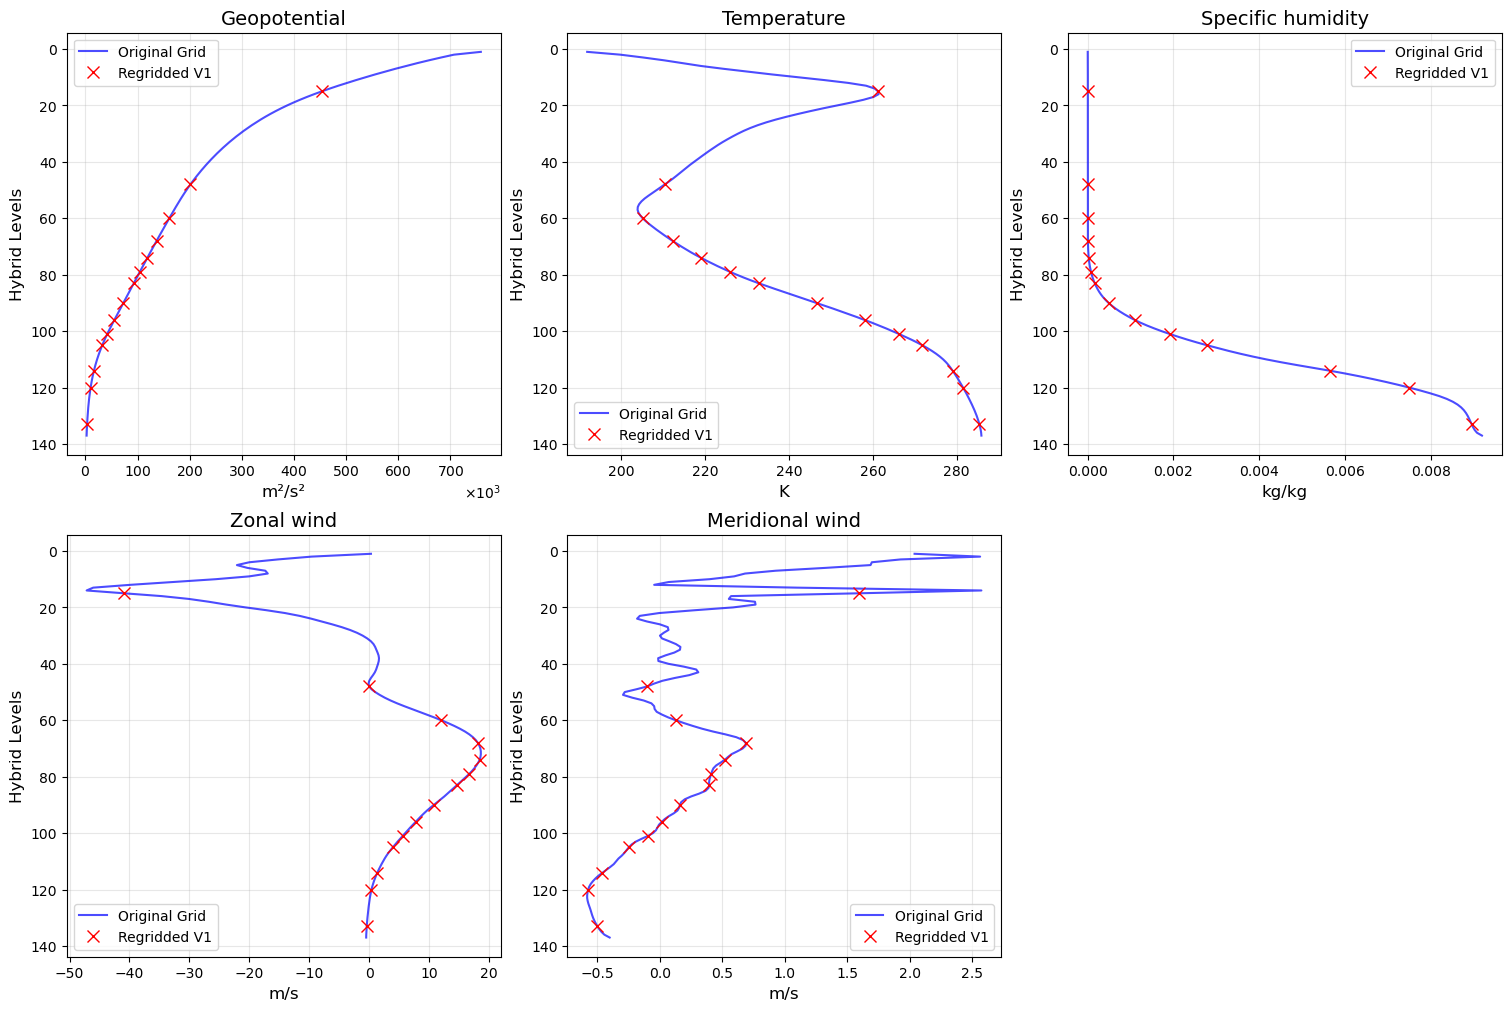

In [13]:
plot_vertical_profiles(ds)

### The Most Important WeatherBench Levels for ARs

For AR dynamics, the lower-tropospheric levels are paramount, but they must be coupled with the upper-level forcing that drives the synoptic system.

**1. The Moisture and Transport Core (Lower Troposphere)**
* **850 hPa & 925 hPa (The MVPs):** These are the most critical levels. The core of the pre-cold-frontal low-level jet (LLJ)—which drives the horizontal moisture flux ($q\mathbf{V}$)—typically maxes out between 900 and 850 hPa. Over 75% of the total water vapor in an AR is usually found below 700 hPa. 
* **1000 hPa:** Vital for capturing surface fluxes (latent and sensible heat) over the ocean and initial friction as the AR makes landfall, though it can become complicated as it intersects with complex coastal topography.
* **700 hPa:** This level often represents the upper boundary of the primary moisture plume. It is also frequently near the freezing level during winter West Coast ARs, making it a critical level for determining the precipitation phase (rain vs. snow).

**2. Synoptic Steering and Forcing (Mid to Upper Troposphere)**
* **500 hPa:** Essential for capturing the mid-level shortwave troughs and large-scale planetary waves that steer the AR corridor.
* **250 hPa & 300 hPa:** These levels capture the upper-level jet streaks. The coupling between the upper-level divergence (right entrance / left exit regions of the jet streak) and the low-level jet is what forces the broad synoptic ascent within the AR.

*(Note: Levels like 50, 100, and 150 hPa are largely irrelevant for AR moisture transport and can often be pruned if you are looking to save computational overhead in a localized downscaling task).*

---

### Where to Add More Layers for ARs

**1. Inside the Low-Level Jet (950 hPa & 900 hPa)**
* **Why:** The wind shear and moisture gradients between 1000 hPa, 925 hPa, and 850 hPa are extremely sharp. The absolute wind maximum of the LLJ frequently sits right at 900 hPa. Adding 950 and 900 hPa allows your model to accurately resolve the height and intensity of the moisture flux core, rather than smearing it across a 75 hPa gap. This is highly beneficial when transitioning into terrain-following vertical coordinates (like Eta or hybrid-sigma) near steep coastal topography.

**2. Resolving the Melting Layer (800 hPa & 750 hPa)**
* **Why:** For downscaling over mountain ranges, accurately projecting hydrological impacts (like runoff vs. snowpack accumulation, which is especially critical over recent burn scars) depends entirely on the height of the 0°C isotherm. This freezing level often fluctuates between 850 hPa and 700 hPa. Adding 800 and 750 hPa gives the model the vertical granularity needed to accurately simulate the melting layer and the latent heat release associated with phase changes as the air mass is forced up the orographic slope.

**3. The Mid-Troposphere Gap (650 hPa & 550 hPa)**
* **Why:** While less critical than the boundary layer, the 100 hPa gaps between 700, 600, and 500 hPa can lead to an underestimation of mid-level stability. In highly intense, deep ARs, moisture is lofted higher into the column. Better resolution here helps capture the moist adiabatic ascent more smoothly.

**The corresponding IFS L137 indices**

* **~950 hPa:** Level 123 *(Calculates to $p_f \approx 950.9$ hPa)*
* **~900 hPa:** Level 118 *(Calculates to $p_f \approx 900.2$ hPa)*
* **~800 hPa:** Level 111 *(Calculates to $p_f \approx 803.9$ hPa)*
* **~750 hPa:** Level 108 *(Calculates to $p_f \approx 751.3$ hPa)*
* **~650 hPa:** Level 103 *(Calculates to $p_f \approx 652.4$ hPa)*
* **~550 hPa:** Level 98 *(Calculates to $p_f \approx 548.0$ hPa)*

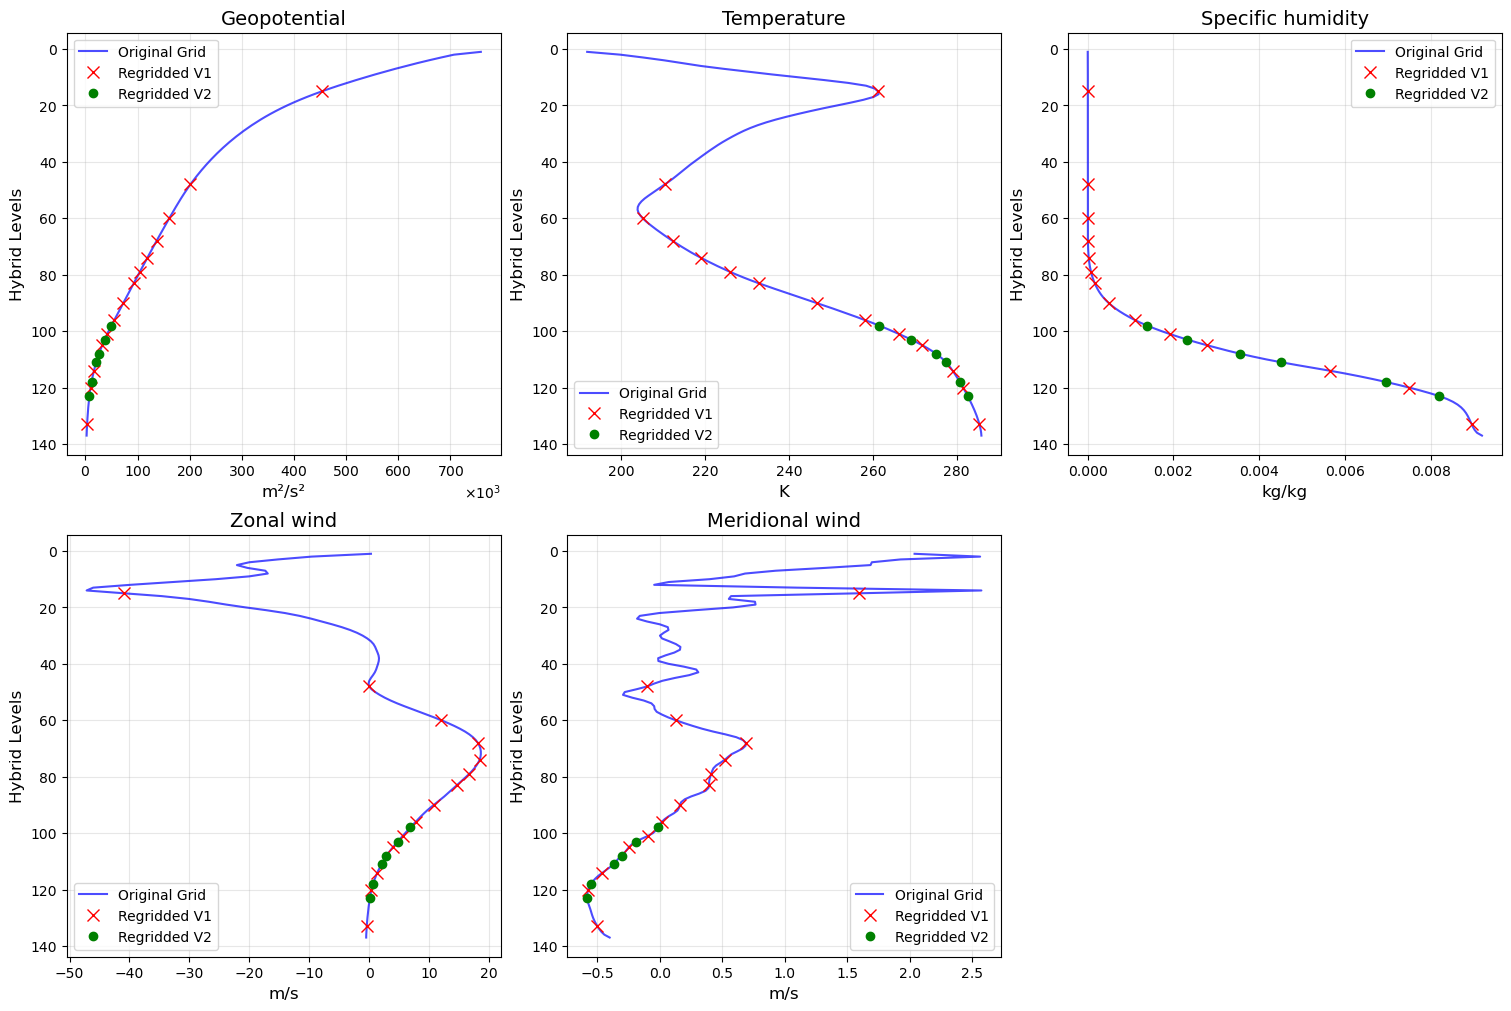

In [14]:
plot_vertical_profiles(ds, auxiliary_subset=True)